In [54]:
from pathlib import Path
import re
import sys

import pandas as pd
import torch

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "diffusion.py").exists() else NOTEBOOK_DIR.parent
ANALYSIS_DIR = PROJECT_ROOT / "experiments-analysis" if (PROJECT_ROOT / "experiments-analysis").exists() else NOTEBOOK_DIR

for path in (PROJECT_ROOT, ANALYSIS_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from diffusion import MaskedDiffusion
from utils import collect_experiment_data


def load_w_matrices(L, l2reg, hebbian=False, fmw=False, dataset="uniform", model="linear", logs_dir="../logs"):
    df = collect_experiment_data(logs_dir=logs_dir)
    df = df[(df["L"] == L) & (df["dataset"] == dataset) & (df["model"] == model)].copy()

    run_dir_col = df["run_dir"].astype(str)
    if hebbian:
        df = df[run_dir_col.str.contains("hebbian", na=False)].copy()
    else:
        df = df[~run_dir_col.str.contains("hebbian", na=False)].copy()

    run_dir_col = df["run_dir"].astype(str)
    if fmw:
        df = df[run_dir_col.str.contains("_fmw", na=False)].copy()
    else:
        df = df[~run_dir_col.str.contains("_fmw", na=False)].copy()

    if not hebbian:
        df = df[df["l2reg"] == l2reg].copy()

    def version_num(run_dir):
        match = re.search(r"(?:^|/)version_(\d+)(?:/|$)", str(run_dir))
        return int(match.group(1)) if match is not None else -1

    df["_version_num"] = df["run_dir"].map(version_num)
    if not df.empty and df["alpha"].duplicated().any():
        df = (
            df.sort_values(["alpha", "_version_num", "run_dir"])
              .groupby("alpha", as_index=False)
              .tail(1)
              .sort_values("alpha")
              .reset_index(drop=True)
        )
    else:
        df = df.sort_values("alpha").reset_index(drop=True)

    run_rows = []
    w_by_alpha = {}
    j_by_alpha = {}

    for _, row in df.iterrows():
        run_dir = Path(row["run_dir"])
        ckpt_path = run_dir / "last.ckpt"
        dataset_path = run_dir / "dataset.pt"
        if (not ckpt_path.exists()) or (not dataset_path.exists()):
            continue

        model = MaskedDiffusion.load_from_checkpoint(str(ckpt_path)).cpu().eval()
        W = model.backbone.W.detach().cpu().clone() * (L**0.5)

        dataset_dict = torch.load(str(dataset_path), map_location="cpu", weights_only=False)
        data_tensor = dataset_dict["dataset"]["data"]
        train_idx = dataset_dict.get("train_idx", None)
        if train_idx is not None and len(train_idx) > 0:
            xi1 = data_tensor[int(train_idx[0])]
        else:
            xi1 = data_tensor[0]
        xi1 = xi1.detach().cpu().flatten().to(dtype=W.dtype)

        if xi1.numel() != W.shape[0] or W.shape[0] != W.shape[1]:
            raise ValueError(
                f"Incompatible shapes for J construction in {run_dir}: xi1 has {xi1.numel()} entries, W has shape {tuple(W.shape)}"
            )

        J = xi1[:, None] * W * xi1[None, :]
        alpha = float(row["alpha"])

        run_rows.append({"alpha": alpha, "run_dir": str(run_dir), "W_shape": tuple(W.shape), "J_shape": tuple(J.shape)})
        w_by_alpha[alpha] = W
        j_by_alpha[alpha] = J

    return pd.DataFrame(run_rows), w_by_alpha, j_by_alpha

In [55]:
rows, w_by_alpha, j_by_alpha = load_w_matrices(L=1024, l2reg=0.01, hebbian=False, fmw=True, dataset="uniform", model="linear", logs_dir="../logs")
print(rows)

   alpha                                            run_dir       W_shape  \
0   0.05  ../logs/linear_uniform_L1024_alpha0.05_l2reg0....  (1024, 1024)   
1   0.10  ../logs/linear_uniform_L1024_alpha0.1_l2reg0.0...  (1024, 1024)   
2   0.15  ../logs/linear_uniform_L1024_alpha0.15_l2reg0....  (1024, 1024)   
3   0.20  ../logs/linear_uniform_L1024_alpha0.2_l2reg0.0...  (1024, 1024)   
4   0.50  ../logs/linear_uniform_L1024_alpha0.5_l2reg0.0...  (1024, 1024)   
5   1.00  ../logs/linear_uniform_L1024_alpha1.0_l2reg0.0...  (1024, 1024)   
6   1.50  ../logs/linear_uniform_L1024_alpha1.5_l2reg0.0...  (1024, 1024)   
7   3.00  ../logs/linear_uniform_L1024_alpha3.0_l2reg0.0...  (1024, 1024)   
8   4.00  ../logs/linear_uniform_L1024_alpha4.0_l2reg0.0...  (1024, 1024)   
9   8.00  ../logs/linear_uniform_L1024_alpha8.0_l2reg0.0...  (1024, 1024)   

        J_shape  
0  (1024, 1024)  
1  (1024, 1024)  
2  (1024, 1024)  
3  (1024, 1024)  
4  (1024, 1024)  
5  (1024, 1024)  
6  (1024, 1024)  
7  (1024

In [56]:
# Analysis: compute q and v, per-alpha histograms, and q/v vs alpha plots
import os
from typing import Any, Dict, Tuple
import numpy as np
import matplotlib.pyplot as plt

def _to_numpy(x):
    try:
        import torch
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x)

def compute_q_v(W: np.ndarray, L: int = None) -> Tuple[np.ndarray, np.ndarray]:
    """Compute q and off-diagonal v values for a matrix W.

    q_i = (1/L) * sum_j W_ij^2
    v_ik = sum_j W_ij * W_kj  (only i != k; returned as a 1D array of off-diagonals)
    """
    W = _to_numpy(W)
    if W.ndim != 2:
        raise ValueError('W must be a 2D array')

    n_rows, n_cols = W.shape
    if L is None:
        L = n_cols

    q = (W ** 2).sum(axis=1) / float(L)

    V = W.dot(W.T)
    mask = ~np.eye(n_rows, dtype=bool)
    v_vals = V[mask]

    return q, v_vals

def _eigs_of_scaled_gram(W: np.ndarray, L: int = None) -> np.ndarray:
    W = _to_numpy(W)
    if W.ndim != 2:
        raise ValueError('W must be a 2D array')
    if L is None:
        L = W.shape[1]
    gram = (W @ W.T) / float(L)
    return np.linalg.eigvalsh(gram)

def plot_eigenvalue_histogram(w_by_alpha: Dict[float, Any], L: int = None, bins: int = 60, plot_dir: str = 'analysis_plots', show: bool = False):
    """Plot one eigenvalue histogram of (1/L) W W^T for each alpha in w_by_alpha."""
    os.makedirs(plot_dir, exist_ok=True)

    eigvals_by_alpha = {}
    for alpha in sorted(w_by_alpha.keys()):
        eigvals = _eigs_of_scaled_gram(w_by_alpha[alpha], L=L)
        eigvals_by_alpha[alpha] = eigvals

        plt.figure(figsize=(6, 4))
        plt.hist(eigvals, bins=bins)
        plt.xlabel('eigenvalue')
        plt.ylabel('count')
        plt.title(f'Eigenvalue histogram of (1/L) W W^T (alpha={alpha})')
        out_path = os.path.join(plot_dir, f'eig_hist_alpha_{float(alpha):.6f}.png')
        plt.tight_layout()
        plt.savefig(out_path)
        if show:
            plt.show()
        plt.close()

    return eigvals_by_alpha

def analyze_W_dict(w_by_alpha: Dict[float, Any], L: int = None, plot_dir: str = 'analysis_plots', show: bool = False):
    """Analyze a dict mapping alpha -> W (numpy or torch tensor).

    Produces per-alpha histograms for q and v, and summary plots (mean +/- std) of q and v vs alpha.
    Returns a dict with computed statistics.
    """
    os.makedirs(plot_dir, exist_ok=True)

    alphas = []
    q_stats = []
    v_stats = []
    per_alpha = {}

    for alpha in sorted(w_by_alpha.keys()):
        W = w_by_alpha[alpha]
        W = _to_numpy(W)
        q_vals, v_vals = compute_q_v(W, L=L)

        plt.figure(figsize=(6, 4))
        plt.hist(q_vals, bins=60)
        plt.xlabel('q')
        plt.ylabel('count')
        plt.title(f'Histogram of q (alpha={alpha})')
        q_hist_path = os.path.join(plot_dir, f'hist_q_alpha_{alpha:.6f}.png')
        plt.tight_layout()
        plt.savefig(q_hist_path)
        if show:
            plt.show()
        plt.close()

        plt.figure(figsize=(6, 4))
        plt.hist(v_vals, bins=60)
        plt.xlabel('v (off-diagonal)')
        plt.ylabel('count')
        plt.title(f'Histogram of v (alpha={alpha})')
        v_hist_path = os.path.join(plot_dir, f'hist_v_alpha_{alpha:.6f}.png')
        plt.tight_layout()
        plt.savefig(v_hist_path)
        if show:
            plt.show()
        plt.close()

        alphas.append(alpha)
        q_mean = float(np.mean(q_vals))
        q_std = float(np.std(q_vals))
        v_mean = float(np.mean(v_vals))
        v_std = float(np.std(v_vals))

        q_stats.append((q_mean, q_std))
        v_stats.append((v_mean, v_std))

        per_alpha[alpha] = {'q_vals': q_vals, 'v_vals': v_vals, 'q_mean': q_mean, 'q_std': q_std, 'v_mean': v_mean, 'v_std': v_std, 'q_hist_path': q_hist_path, 'v_hist_path': v_hist_path}

    alphas_arr = np.array(alphas)
    q_means = np.array([m for m, s in q_stats])
    q_stds = np.array([s for m, s in q_stats])
    v_means = np.array([m for m, s in v_stats])
    v_stds = np.array([s for m, s in v_stats])

    plt.figure(figsize=(6, 4))
    plt.errorbar(alphas_arr, q_means, yerr=q_stds, fmt='-o', capsize=4)
    plt.xlabel('alpha')
    plt.ylabel('q mean')
    plt.title('q mean vs alpha (error bars = std)')
    q_vs_alpha_path = os.path.join(plot_dir, 'q_vs_alpha.png')
    plt.tight_layout()
    plt.savefig(q_vs_alpha_path)
    if show:
        plt.show()
    plt.close()

    plt.figure(figsize=(6, 4))
    plt.errorbar(alphas_arr, v_means, yerr=v_stds, fmt='-o', capsize=4)
    plt.xlabel('alpha')
    plt.ylabel('v mean (off-diagonal)')
    plt.title('v mean vs alpha (error bars = std)')
    v_vs_alpha_path = os.path.join(plot_dir, 'v_vs_alpha.png')
    plt.tight_layout()
    plt.savefig(v_vs_alpha_path)
    if show:
        plt.show()
    plt.close()

    stats = {
        'per_alpha': per_alpha,
        'alphas': alphas_arr,
        'q_means': q_means,
        'q_stds': q_stds,
        'v_means': v_means,
        'v_stds': v_stds,
        'q_vs_alpha_path': q_vs_alpha_path,
        'v_vs_alpha_path': v_vs_alpha_path,
    }

    return stats

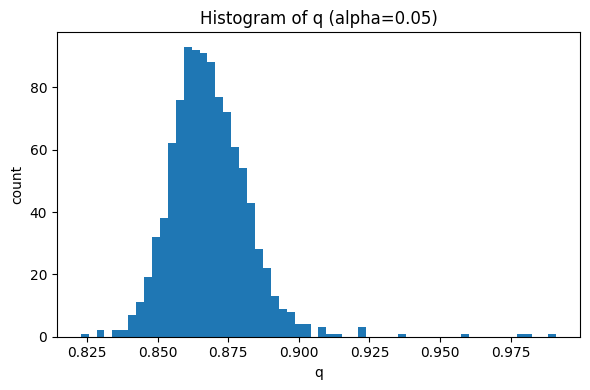

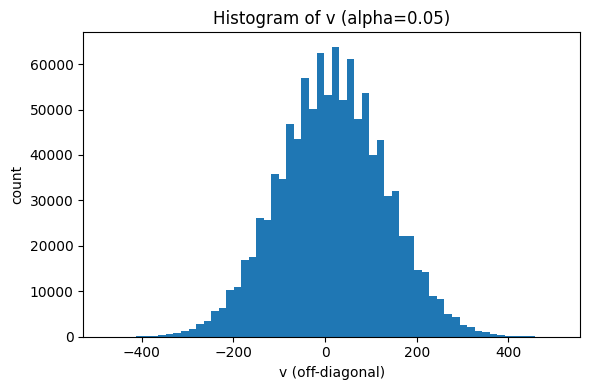

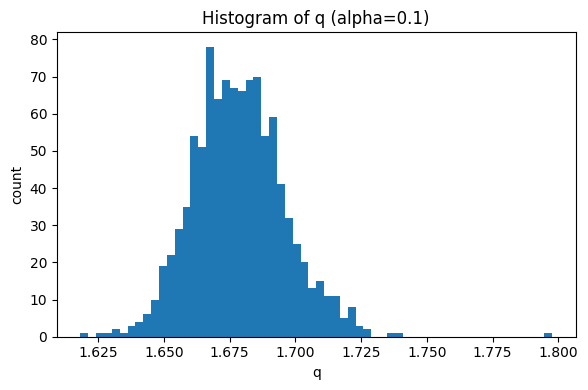

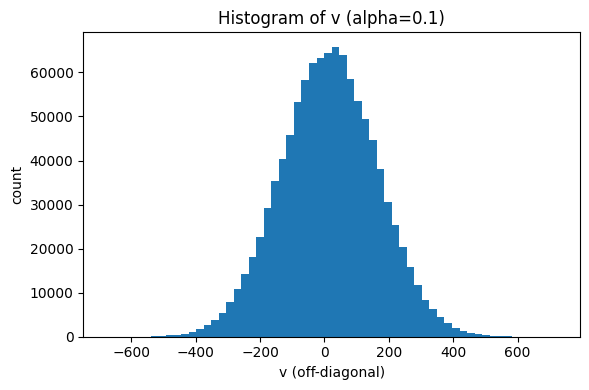

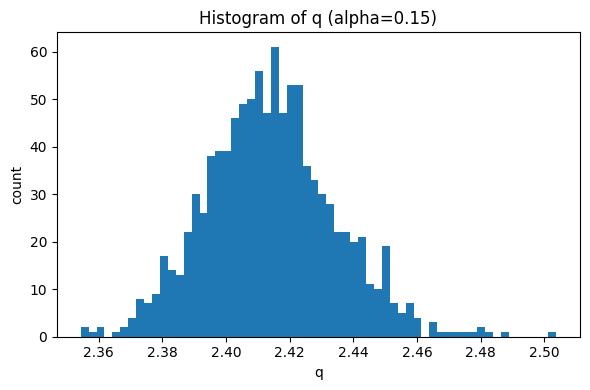

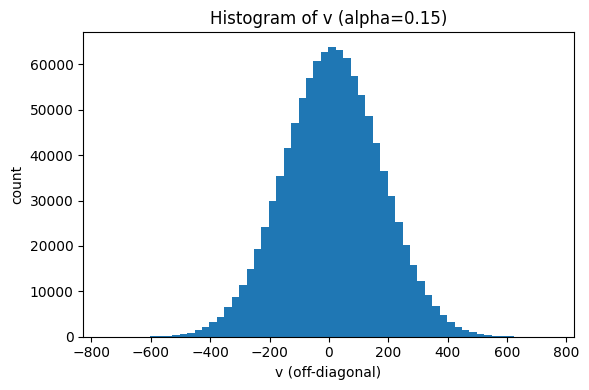

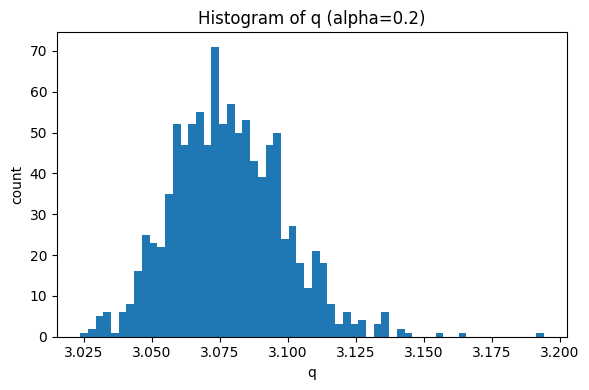

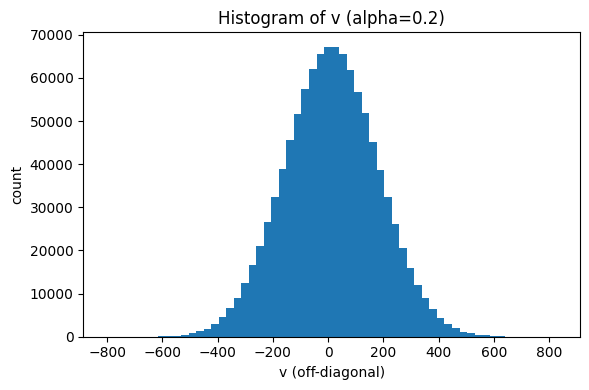

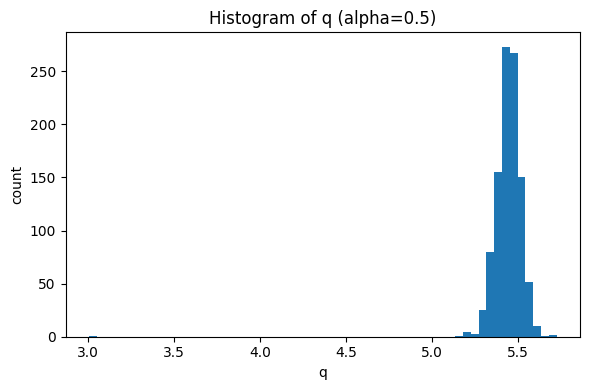

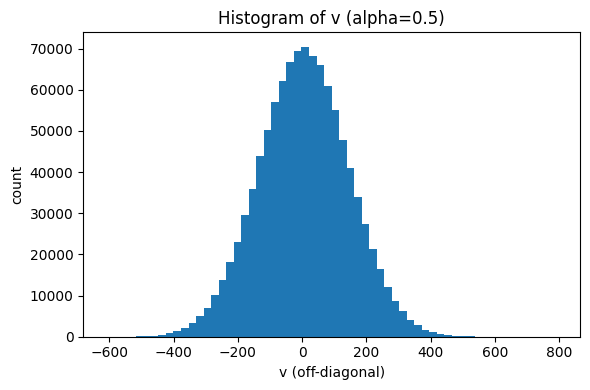

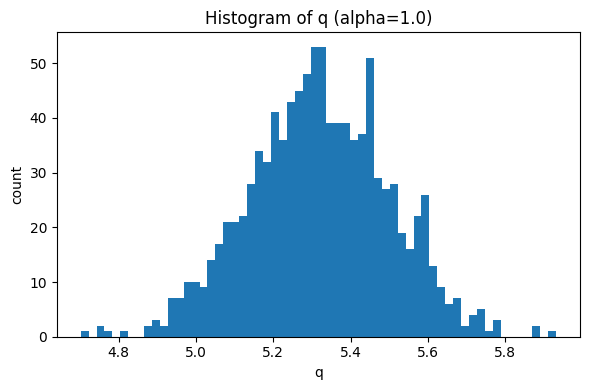

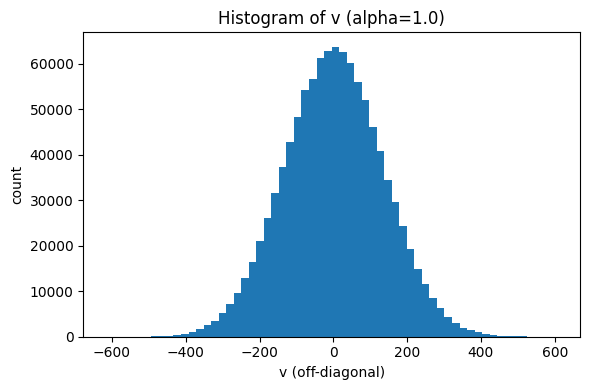

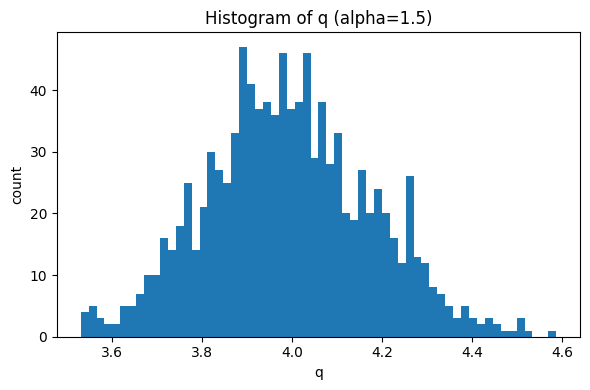

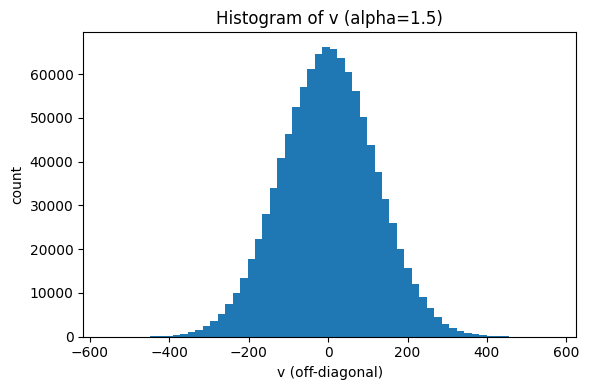

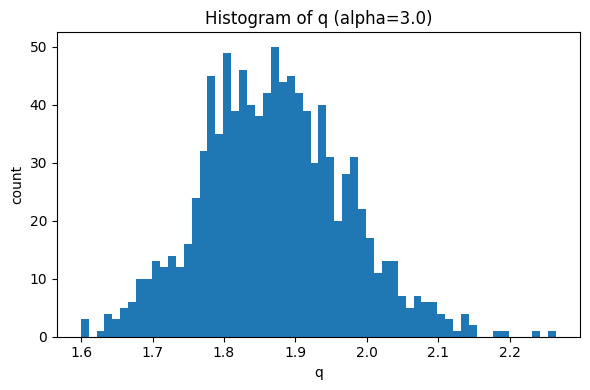

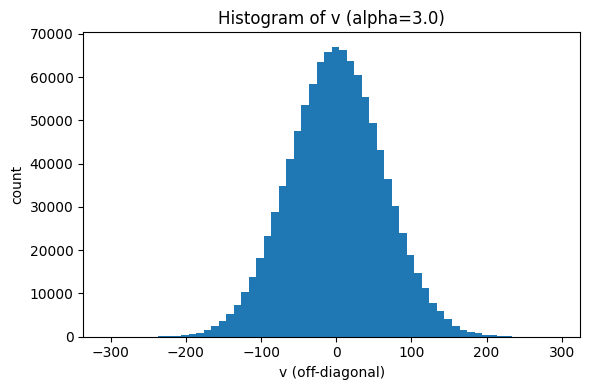

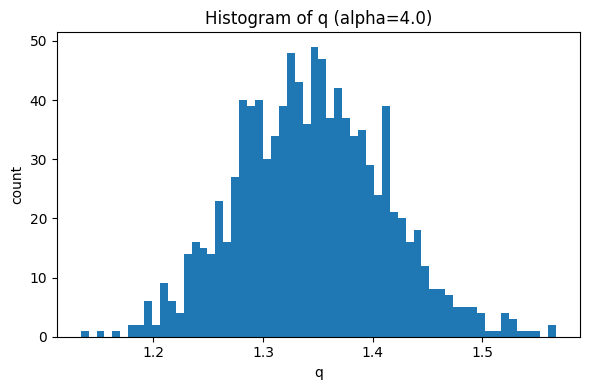

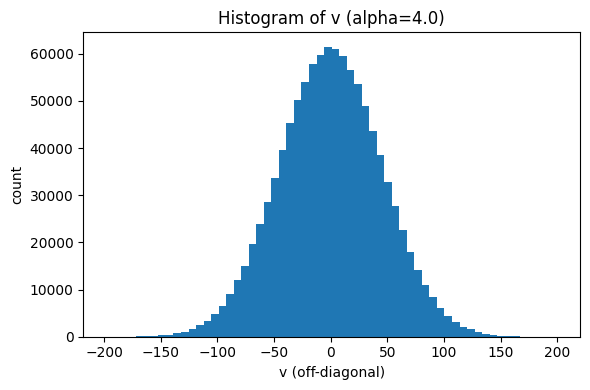

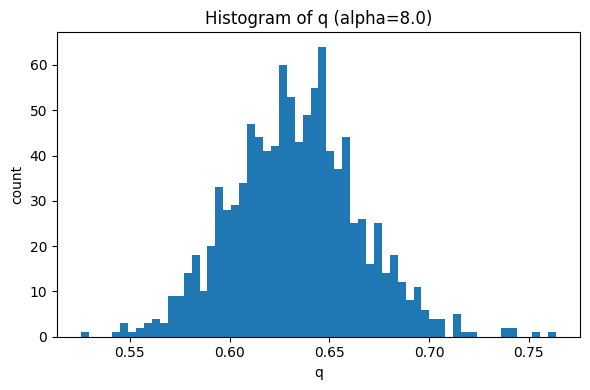

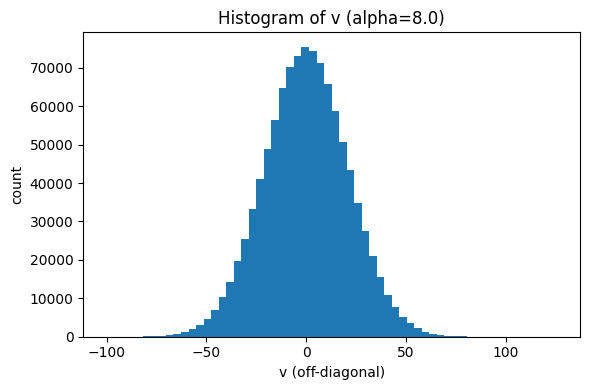

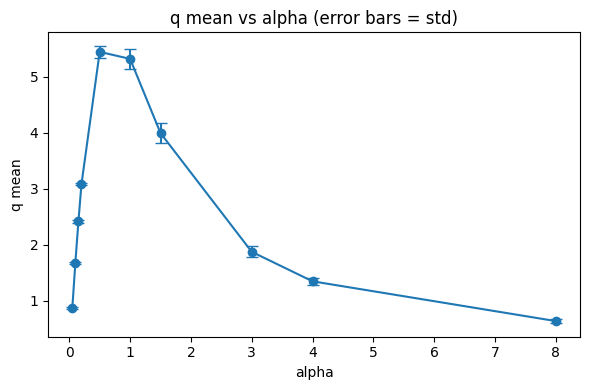

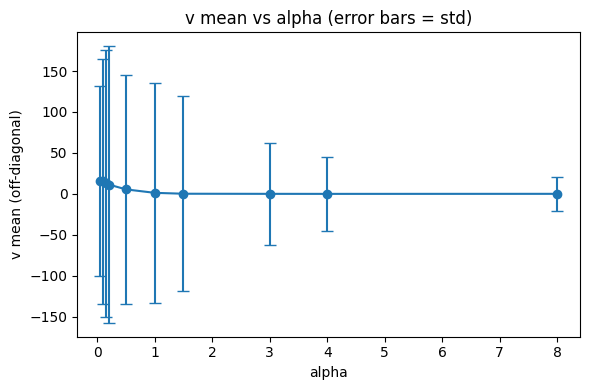

In [57]:
stats = analyze_W_dict(j_by_alpha, L=1024, plot_dir='analysis_plots', show=True)

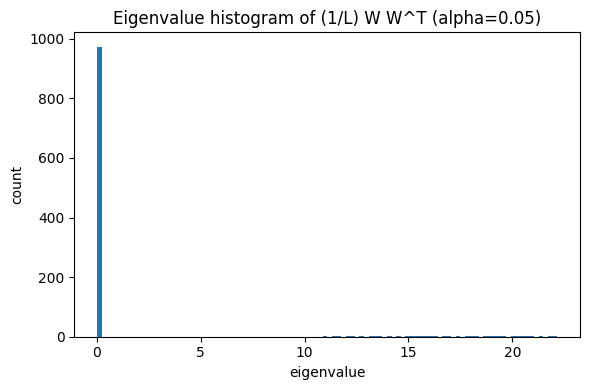

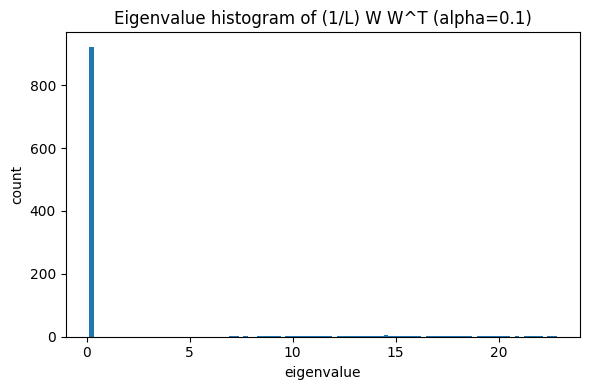

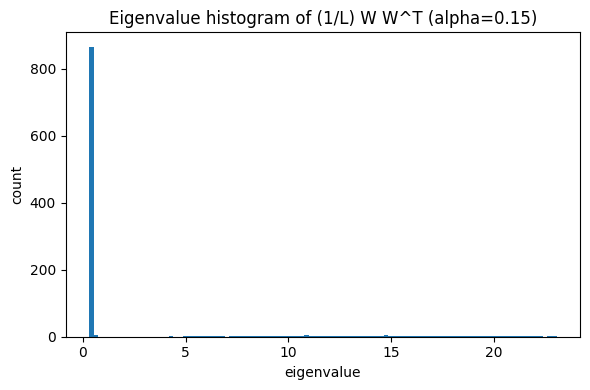

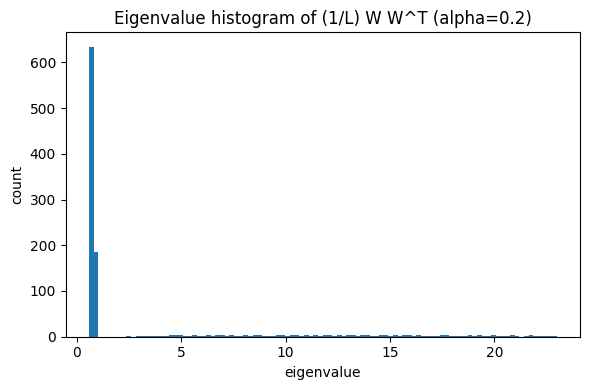

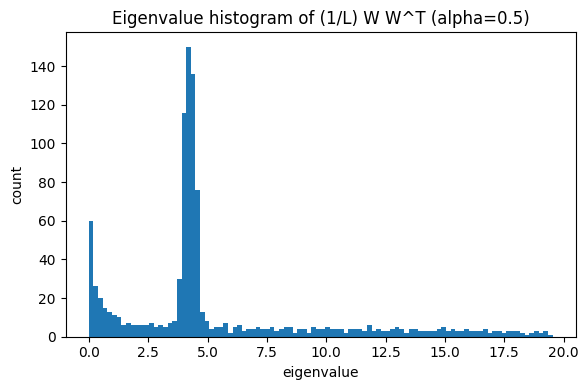

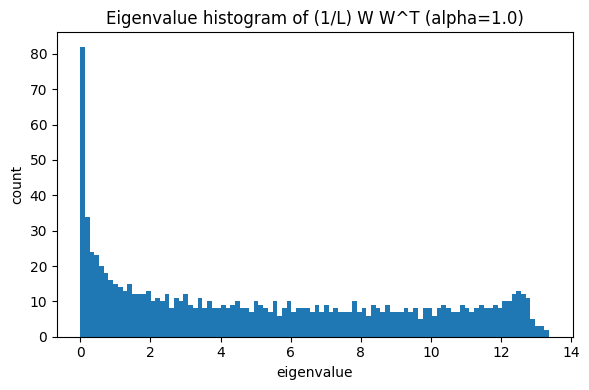

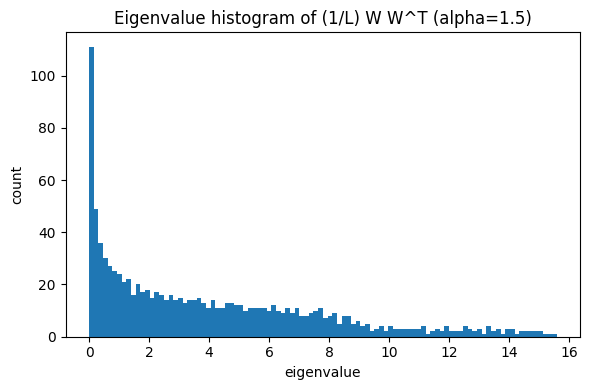

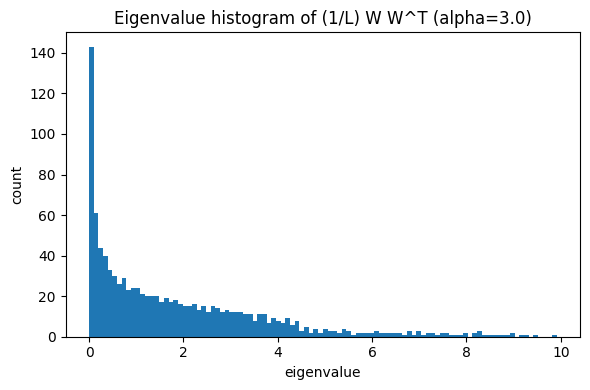

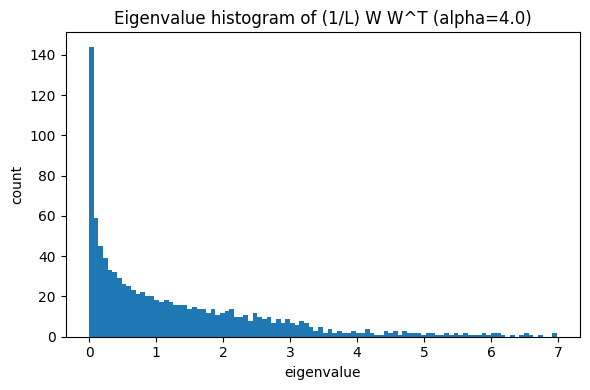

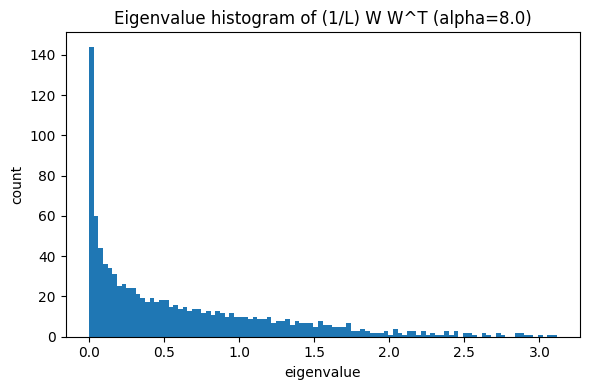

{0.05: array([2.0686556e-02, 2.0948181e-02, 2.1104127e-02, ..., 2.1370514e+01,
        2.1743517e+01, 2.2153318e+01], dtype=float32),
 0.1: array([ 0.11987946,  0.12002752,  0.1208984 , ..., 22.082132  ,
        22.568785  , 22.813478  ], dtype=float32),
 0.15: array([ 0.30766746,  0.30869576,  0.30975834, ..., 22.278284  ,
        22.771496  , 23.04489   ], dtype=float32),
 0.2: array([ 0.579806  ,  0.58584493,  0.58712655, ..., 22.601866  ,
        22.747719  , 22.978024  ], dtype=float32),
 0.5: array([2.20761919e-07, 1.05126936e-04, 5.01776871e-04, ...,
        1.92772865e+01, 1.93307323e+01, 1.95320454e+01], dtype=float32),
 1.0: array([4.37131057e-05, 5.24895731e-05, 2.23872383e-04, ...,
        1.31999025e+01, 1.32718725e+01, 1.33750734e+01], dtype=float32),
 1.5: array([8.0469808e-06, 2.6391057e-05, 1.2271483e-04, ..., 1.5251690e+01,
        1.5294101e+01, 1.5581812e+01], dtype=float32),
 3.0: array([5.3518283e-07, 2.8589804e-05, 3.0346349e-05, ..., 9.2514029e+00,
        9.476

In [52]:
plot_eigenvalue_histogram(w_by_alpha, L=1024, bins=100, plot_dir='analysis_plots', show=True)